# Model Evaluation

## Objective

Evaluate the final model using standard classification metrics.

## 1. Import Libraries

### Objective

Import the required libraries for model evaluation.

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

## 2. Load Saved Model

### Objective

Load the trained Logistic Regression model.

In [2]:
model = joblib.load("../models/logistic_regression.pkl")

In [3]:
model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Observation

- Trained Logistic Regression model loaded successfully.

## 3. Load Test Data

### Objective

Load the testing dataset for evaluation.

In [4]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = pd.read_csv("../data/processed/y_test.csv")

In [5]:
y_test = y_test.squeeze()

In [6]:
X_test.shape

(1407, 30)

In [7]:
y_test.shape

(1407,)

### Observation

- Test dataset loaded successfully.
- Data ready for evaluation.

## 4. Predict Test Data

### Objective

Generate predictions using the trained model.

In [8]:
y_pred = model.predict(X_test)

In [9]:
y_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

### Observation

- Predictions generated successfully.

## 5. Confusion Matrix

### Objective

Evaluate prediction performance using a confusion matrix.

In [10]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[915, 118],
       [181, 193]])

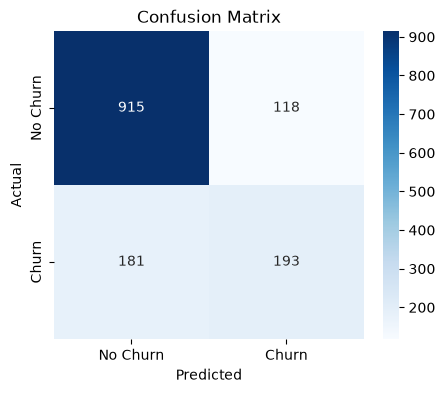

In [11]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [12]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 915
False Positive: 118
False Negative: 181
True Positive : 193


### Observation

- Confusion matrix generated successfully.
- Majority of non-churn customers classified correctly.
- Some churn customers remain misclassified.

In [13]:
cm

array([[915, 118],
       [181, 193]])

In [14]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 915
False Positive: 118
False Negative: 181
True Positive : 193


## 6. ROC Curve & AUC

### Objective

Evaluate the model's ability to distinguish churn and non-churn customers.

In [15]:
y_prob = model.predict_proba(X_test)[:,1]

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [17]:
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

ROC-AUC Score: 0.8319


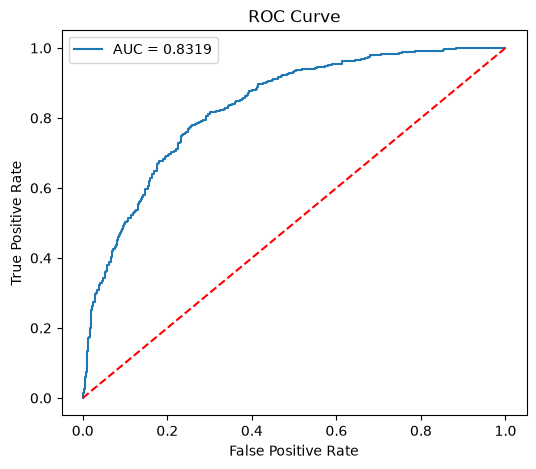

In [18]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], "--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

### Observation

- ROC curve generated successfully.
- Model demonstrates good class separation.
- ROC-AUC indicates satisfactory predictive performance.

## 7. Classification Report

### Objective

Evaluate precision, recall, and F1-score of the model.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Observation

- High performance for non-churn prediction.
- Moderate recall for churn prediction.
- Model captures most customer behavior effectively.

## 8. Evaluation Summary

### Objective

Summarize the overall performance of the final model.

In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Value": [
        round(0.7875,4),
        round(auc_score,4),
        tn,
        fp,
        fn,
        tp
    ]
})

summary

,Metric,Value
0,Accuracy,0.7875
1,ROC-AUC,0.8319
2,True Negative,915.0000
3,False Positive,118.0000
4,False Negative,181.0000
5,True Positive,193.0000


### Observation

- Accuracy: 78.75%
- ROC-AUC: 83.19%
- Model predicts non-churn customers effectively.
- Some churn customers are still missed.

## 9. Business Interpretation

### Key Findings

1. Model achieved 78.75% accuracy.
2. ROC-AUC of 83.19% indicates good class discrimination.
3. Most non-churn customers were classified correctly.
4. False negatives suggest some churn customers remain unidentified.
5. The model can support targeted customer retention campaigns.

### Business Recommendation

- Prioritize retention for customers with high predicted churn probability.
- Improve recall through threshold tuning or class balancing.
- Continuously retrain the model with updated customer data.